# Préparation de la Data

In [15]:
import pandas as pd

transactions = pd.read_csv('transactions.csv', sep=";")
customers = pd.read_csv('customers.csv', sep=";")
products = pd.read_csv('products.csv', sep=";")

transactions.info()
customers.info()
products.info()

<ipython-input-15-5760cbad0b10>:3: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  transactions = pd.read_csv('transactions.csv', sep=";")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     687534 non-null  object
 1   date        687534 non-null  object
 2   session_id  687534 non-null  object
 3   client_id   687534 non-null  object
dtypes: object(4)
memory usage: 32.0+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8621 entries, 0 to 8620
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8621 non-null   object
 1   sex        8621 non-null   object
 2   birth      8621 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_prod  3286 non-null   object 
 1   price    3286 non-null 

In [16]:
transactions_customers = pd.merge(transactions, customers, on='client_id', how='left') #faire l'analyse avec indicator true
transactions_customers_products = pd.merge(transactions_customers, products, on='id_prod', how='outer')
df_merge = transactions_customers_products
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048596 entries, 0 to 1048595
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id_prod     687555 non-null  object 
 1   date        687534 non-null  object 
 2   session_id  687534 non-null  object 
 3   client_id   687534 non-null  object 
 4   sex         687534 non-null  object 
 5   birth       687534 non-null  float64
 6   price       687555 non-null  float64
 7   categ       687555 non-null  float64
dtypes: float64(3), object(5)
memory usage: 64.0+ MB


In [17]:
print(f"Minimum birth date: {df_merge['birth'].min()}")
print(f"Maximum birth date: {df_merge['birth'].max()}")

Minimum birth date: 1929.0
Maximum birth date: 2004.0


In [18]:
df_merge['age'] = 2022 - df_merge['birth'].astype(float).fillna(0).astype(int)

In [19]:
df_merge.head()

,id_prod,date,session_id,client_id,sex,birth,price,categ,age
0,0_0,2021-03-01 13:45:51.575117,s_282,c_5152,f,1986.0,3.75,0.0,36
1,0_0,2021-03-02 06:42:55.351333,s_621,c_2917,m,1988.0,3.75,0.0,34
2,0_0,2021-03-02 18:49:49.651862,s_852,c_3988,f,1962.0,3.75,0.0,60
3,0_0,2021-03-02 21:57:33.862118,s_908,c_1004,m,1973.0,3.75,0.0,49
4,0_0,2021-03-03 23:59:48.997483,s_1379,c_278,f,1987.0,3.75,0.0,35


# Demandes de Annabelle

Chiffre d’affaires avec moyenne mobile

<ipython-input-20-6c02bce2bde5>:6: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  df_trimestriel = df_merge.groupby(pd.Grouper(key='date', freq='Q'))['price'].sum().reset_index()


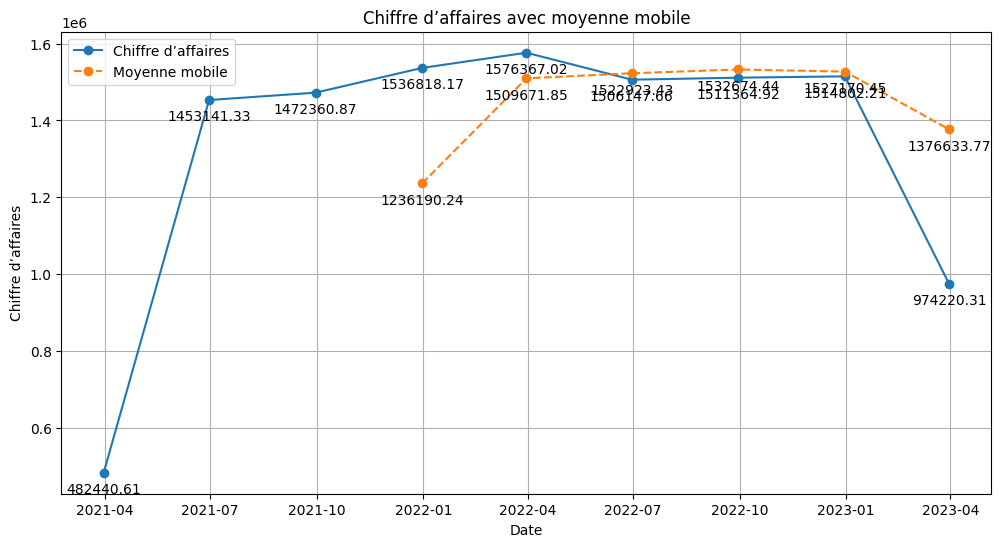

In [20]:
import matplotlib.pyplot as plt

df_merge['date'] = pd.to_datetime(df_merge['date'])
df_merge = df_merge.sort_values(by='date')

df_trimestriel = df_merge.groupby(pd.Grouper(key='date', freq='Q'))['price'].sum().reset_index()
df_trimestriel['moyenne_mobile'] = df_trimestriel['price'].rolling(window=4).mean()

plt.figure(figsize=(12, 6))
plt.plot(df_trimestriel['date'], df_trimestriel['price'], marker='o', label='Chiffre d’affaires')
plt.plot(df_trimestriel['date'], df_trimestriel['moyenne_mobile'], marker='o', linestyle='--', label='Moyenne mobile')

# Affichage des valeurs pour chaque point
for i in range(len(df_trimestriel)):
    # Annotation pour le chiffre d'affaires
    plt.annotate(f'{df_trimestriel["price"].iloc[i]:.2f}',
                 (df_trimestriel['date'].iloc[i], df_trimestriel["price"].iloc[i]),
                 textcoords="offset points", xytext=(0,-15), ha='center')

    # Annotation pour la moyenne mobile (vérification pour éviter les NaN)
    if not pd.isna(df_trimestriel["moyenne_mobile"].iloc[i]):
        plt.annotate(f'{df_trimestriel["moyenne_mobile"].iloc[i]:.2f}',
                     (df_trimestriel['date'].iloc[i], df_trimestriel["moyenne_mobile"].iloc[i]),
                     textcoords="offset points", xytext=(0,-15), ha='center')

plt.xlabel('Date')
plt.ylabel('Chiffre d’affaires')
plt.title('Chiffre d’affaires avec moyenne mobile')
plt.legend()
plt.grid(True)

plt.show()


Chiffre d'affaires par catégorie

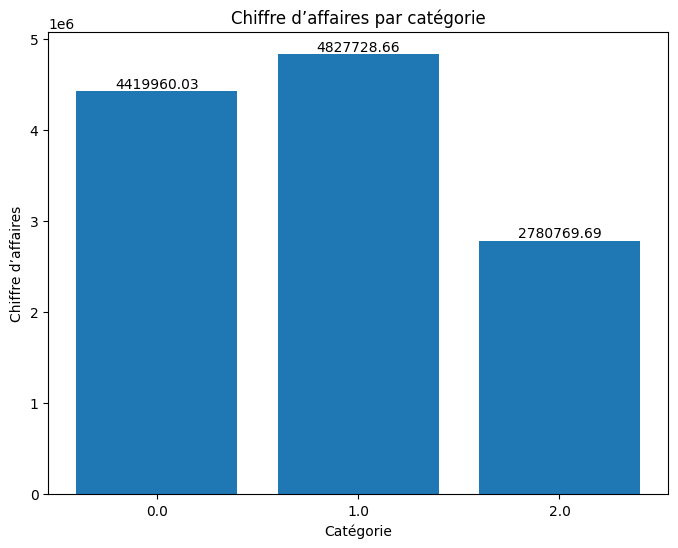

In [21]:
# Filtrer les catégories 0, 1 et 2
df_cat = (
    df_merge[df_merge['categ'].isin([0, 1, 2])]
    .groupby('categ')['price']
    .sum()
    .reset_index()
)

# Convertir en string pour un affichage nominal
df_cat['categ'] = df_cat['categ'].astype(str)

plt.figure(figsize=(8, 6))

# Bar chart
bars = plt.bar(df_cat['categ'], df_cat['price'])

plt.xlabel('Catégorie')
plt.ylabel('Chiffre d’affaires')
plt.title('Chiffre d’affaires par catégorie')

# Affichage des valeurs sur chaque barre
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom'
    )

plt.show()

In [22]:
#verif lien entre les deux categorie
from scipy.stats import chi2_contingency

# Découper les prix en 4 quartiles sur tout le DataFrame
df_merge['price_quartile'] = pd.qcut(df_merge['price'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# Créer une table de contingence : catégorie vs quartile de prix
contingency = pd.crosstab(df_merge['categ'], df_merge['price_quartile'])

# Appliquer le test du chi²
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi² = {chi2:.4f}")
print(f"p-value = {p:.4e}")
print(f"Degrés de liberté = {dof}")

Chi² = 357811.7434
p-value = 0.0000e+00
Degrés de liberté = 6


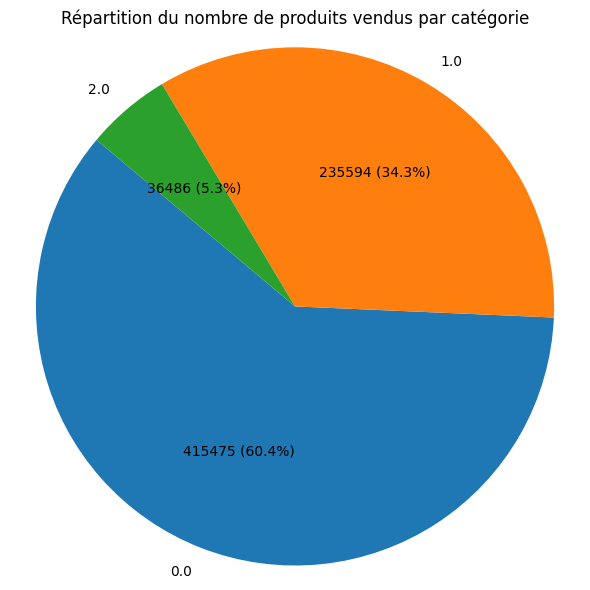

In [23]:
resultat = df_merge.groupby('categ').size().reset_index(name='nb_produits_vendus')

# Préparation des données pour le pie chart
labels = resultat['categ']
values = resultat['nb_produits_vendus']

# Fonction pour afficher à la fois la valeur absolue et le pourcentage
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f"{val} ({pct:.1f}%)"
    return my_autopct

# Création du pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    values,
    labels=labels,
    autopct=make_autopct(values),
    startangle=140  # Pour orienter le camembert si besoin
)

plt.title("Répartition du nombre de produits vendus par catégorie")
plt.axis('equal')  # Assure un camembert circulaire
plt.tight_layout()
plt.show()


In [24]:
#verif de correlation lineaire
from scipy.stats import pearsonr

resultat = df_merge.groupby('categ').size().reset_index(name='nb_produits_vendus')

# Attention : s'assurer que 'categ' est bien numérique
resultat['categ'] = resultat['categ'].astype(int)

corr, p_value = pearsonr(resultat['categ'], resultat['nb_produits_vendus'])

print(f"Coefficient de Pearson : {corr:.4f}")
print(f"p-value : {p_value:.4e}")


Coefficient de Pearson : -0.9996
p-value : 1.8641e-02


Nombre de clients par mois

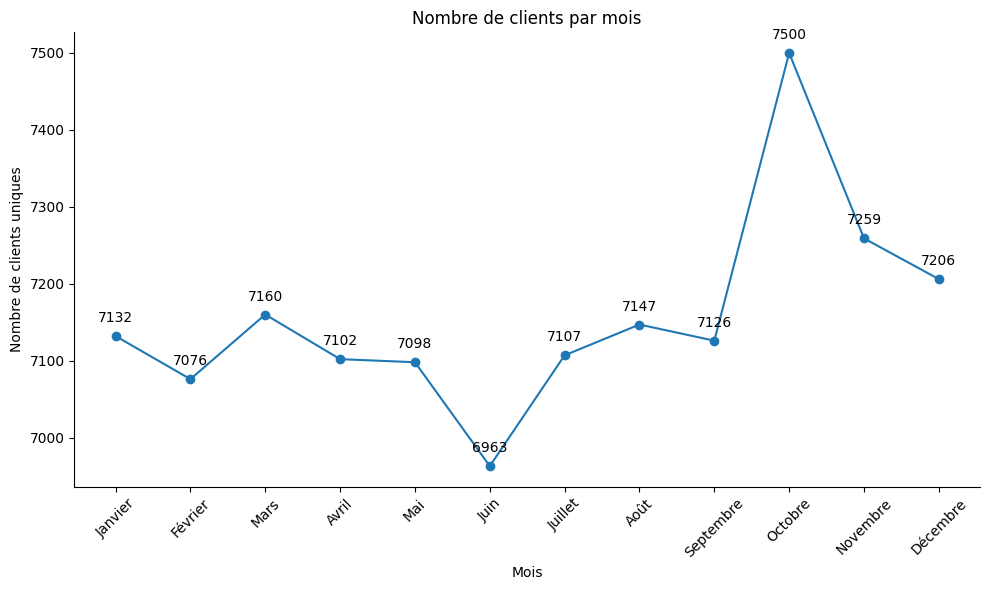

In [25]:
mois_fr = {
    1: 'Janvier', 2: 'Février', 3: 'Mars', 4: 'Avril',
    5: 'Mai', 6: 'Juin', 7: 'Juillet', 8: 'Août',
    9: 'Septembre', 10: 'Octobre', 11: 'Novembre', 12: 'Décembre'
}

df_merge['month'] = df_merge['date'].dt.month
df_merge['mois_nom'] = df_merge['month'].map(mois_fr)


df_client = df_merge.groupby('mois_nom')['client_id'].nunique().reset_index()


mois_ordre = ['Janvier', 'Février', 'Mars', 'Avril', 'Mai', 'Juin',
              'Juillet', 'Août', 'Septembre', 'Octobre', 'Novembre', 'Décembre']
df_client['mois_nom'] = pd.Categorical(df_client['mois_nom'], categories=mois_ordre, ordered=True)
df_client = df_client.sort_values('mois_nom')

plt.figure(figsize=(10,6))
plt.plot(df_client['mois_nom'], df_client['client_id'], marker='o', linestyle='-')
plt.xlabel('Mois')
plt.ylabel('Nombre de clients uniques')
plt.title('Nombre de clients par mois')
plt.xticks(rotation=45)

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

for index, row in df_client.iterrows():
    plt.annotate(f'{row["client_id"]}', (row['mois_nom'], row['client_id']), textcoords="offset points", xytext=(0,10), ha='center')

plt.tight_layout()
plt.show()

Nombre de transactions

In [26]:
n_transactions = df_merge.shape[0]
print("Nombre de transactions :", n_transactions)

Nombre de transactions : 1048596


Nombre de produit vendus

In [27]:
nb_produits = df_merge['id_prod'].nunique()
print("Nombre de produits vendus :", nb_produits)

Nombre de produits vendus : 3286


Les tops...

In [28]:
df_perf = df_merge.groupby('id_prod').agg(
    nb_ventes=('id_prod', 'count'),
    ca=('price', 'sum')
).reset_index()

df_top_ca = df_perf.sort_values(by='ca', ascending=False).head(10)
df_top_nb_vente = df_perf.sort_values(by='nb_ventes', ascending=False).head(10)
df_flop_ca = df_perf.sort_values(by='ca', ascending=True).head(10)
df_flop_nb_vente = df_perf.sort_values(by='nb_ventes', ascending=True).head(10)

...en CA

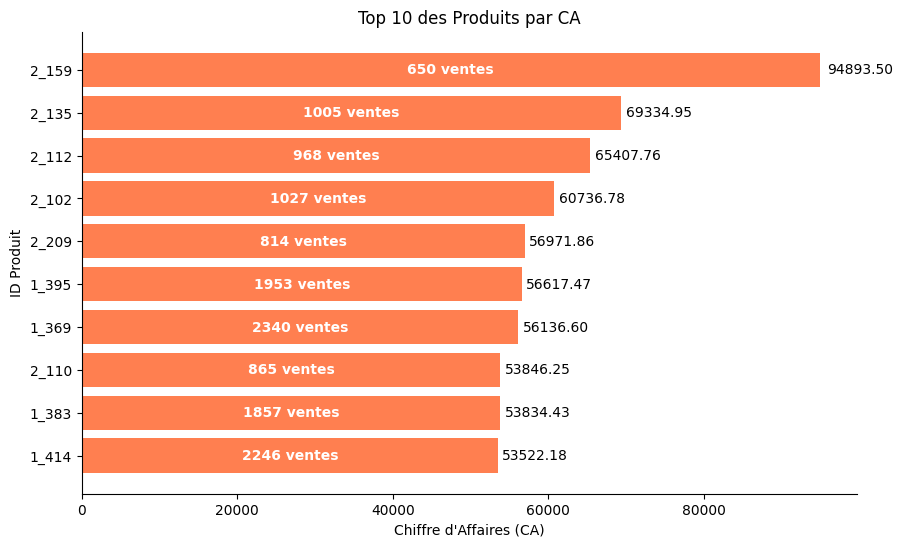

In [29]:
bar_color = 'coral'

df_top_ca = df_top_ca.sort_values(by='ca', ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.barh(df_top_ca['id_prod'], df_top_ca['ca'], color=bar_color)
plt.xlabel("Chiffre d'Affaires (CA)")
plt.ylabel("ID Produit")
plt.title("Top 10 des Produits par CA")

ax = plt.gca()  # Récupérer l'axe courant
ax.invert_yaxis()  # Inverser l'axe des y

# Supprimer l'encadrement en haut et à droite
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, nb, ca in zip(bars, df_top_ca['nb_ventes'], df_top_ca['ca']):
    width = bar.get_width()
    y_center = bar.get_y() + bar.get_height() / 2
    plt.text(width / 2, y_center, f"{nb} ventes", va='center', ha='center', color='white', fontweight='bold')
    plt.text(width + width * 0.01, y_center, f"{ca:.2f}", va='center', ha='left', color='black')

plt.show()

...en nombre de vente

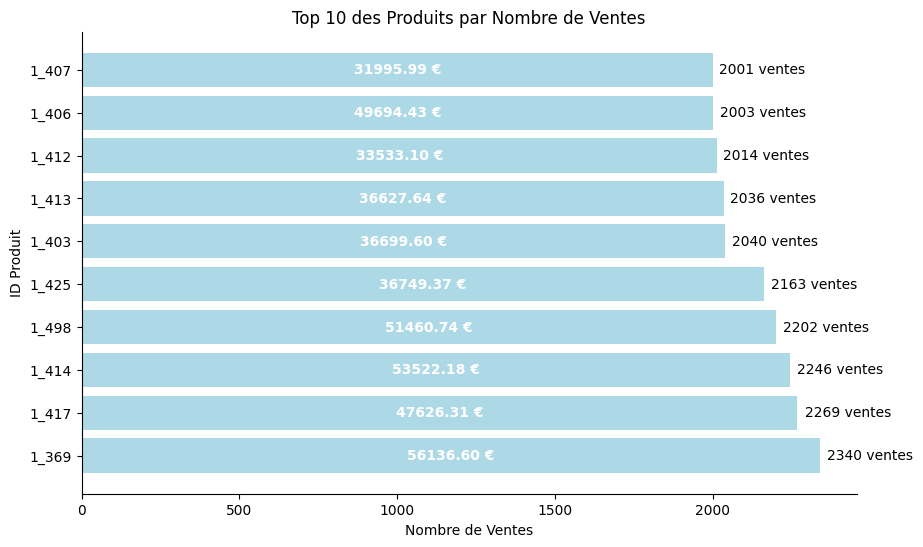

In [30]:
bar_color = 'lightblue'

df_top_nb_vente = df_top_nb_vente.sort_values(by='nb_ventes', ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.barh(df_top_nb_vente['id_prod'], df_top_nb_vente['nb_ventes'], color=bar_color)
plt.xlabel("Nombre de Ventes")
plt.ylabel("ID Produit")
plt.title("Top 10 des Produits par Nombre de Ventes")
plt.gca().invert_yaxis()

ax = plt.gca()  # Récupérer l'axe courant
ax.invert_yaxis()  # Inverser l'axe des y

# Supprimer l'encadrement en haut et à droite
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, nb, ca in zip(bars, df_top_nb_vente['nb_ventes'], df_top_nb_vente['ca']):
    width = bar.get_width()
    y_center = bar.get_y() + bar.get_height() / 2
    plt.text(width / 2, y_center, f"{ca:.2f} €", va='center', ha='center', color='white', fontweight='bold')
    plt.text(width + width * 0.01, y_center, f"{nb} ventes", va='center', ha='left', color='black')

plt.show()

In [31]:
#Verif correlation lineaire
# Pour l'ensemble des livres
corr_all, p_all = pearsonr(df_perf['nb_ventes'], df_perf['ca'])

print(f"[ENSEMBLE] Coefficient de Pearson : {corr_all:.4f}")
print(f"[ENSEMBLE] p-value : {p_all:.4e}")

[ENSEMBLE] Coefficient de Pearson : 0.7608
[ENSEMBLE] p-value : 0.0000e+00


Les flops...

...en CA

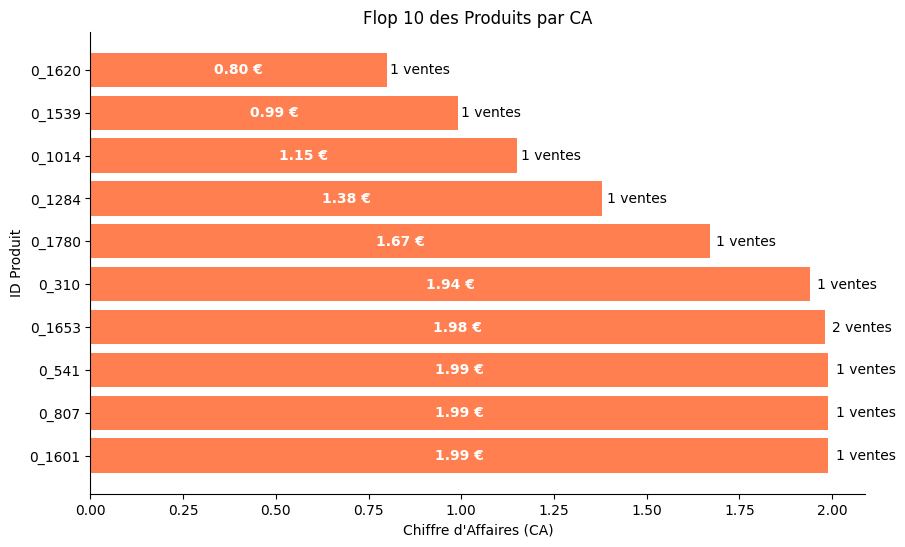

In [32]:
bar_color = 'coral'

df_flop_ca = df_flop_ca.sort_values(by='ca', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(df_flop_ca['id_prod'], df_flop_ca['ca'], color=bar_color)
plt.xlabel("Chiffre d'Affaires (CA)")
plt.ylabel("ID Produit")
plt.title("Flop 10 des Produits par CA")

ax = plt.gca()
ax.invert_yaxis()

# Enlever l'encadrement en haut et à droite
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, nb, ca in zip(bars, df_flop_ca['nb_ventes'], df_flop_ca['ca']):
    width = bar.get_width()
    y_center = bar.get_y() + bar.get_height() / 2
    plt.text(width / 2, y_center, f"{ca:.2f} €", va='center', ha='center', color='white', fontweight='bold')
    plt.text(width + width * 0.01, y_center, f"{nb} ventes", va='center', ha='left', color='black')

plt.show()

...en nombre de vente

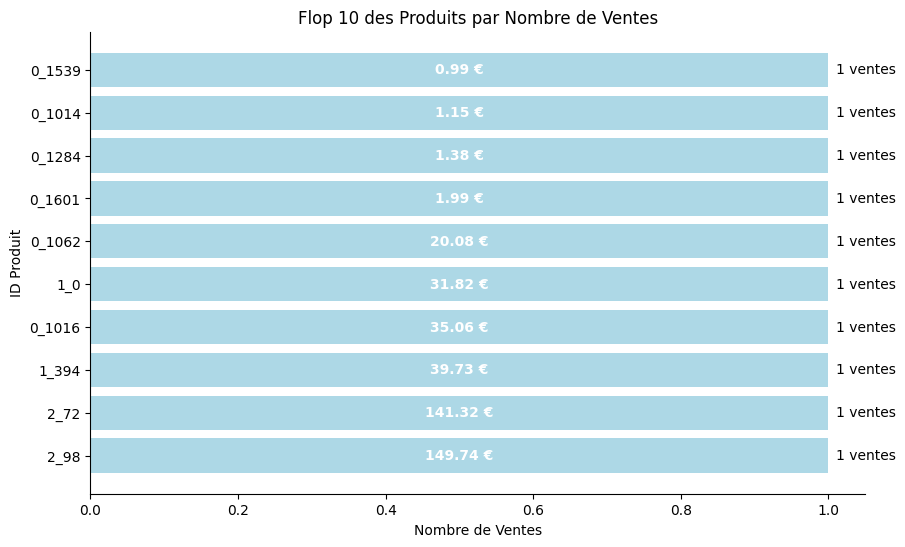

In [33]:
bar_color = 'lightblue'

df_flop_nb_vente = df_flop_nb_vente.sort_values(by=['nb_ventes', 'ca'], ascending=[False, False])

plt.figure(figsize=(10, 6))
bars = plt.barh(df_flop_nb_vente['id_prod'], df_flop_nb_vente['nb_ventes'], color=bar_color)
plt.xlabel("Nombre de Ventes")
plt.ylabel("ID Produit")
plt.title("Flop 10 des Produits par Nombre de Ventes")

ax = plt.gca()
# Enlever l'encadrement en haut et à droite
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, nb, ca in zip(bars, df_flop_nb_vente['nb_ventes'], df_flop_nb_vente['ca']):
    width = bar.get_width()
    y_center = bar.get_y() + bar.get_height() / 2
    plt.text(width / 2, y_center, f"{ca:.2f} €", va='center', ha='center', color='white', fontweight='bold')
    plt.text(width + width * 0.01, y_center, f"{nb} ventes", va='center', ha='left', color='black')

plt.show()

La répartition des catégories

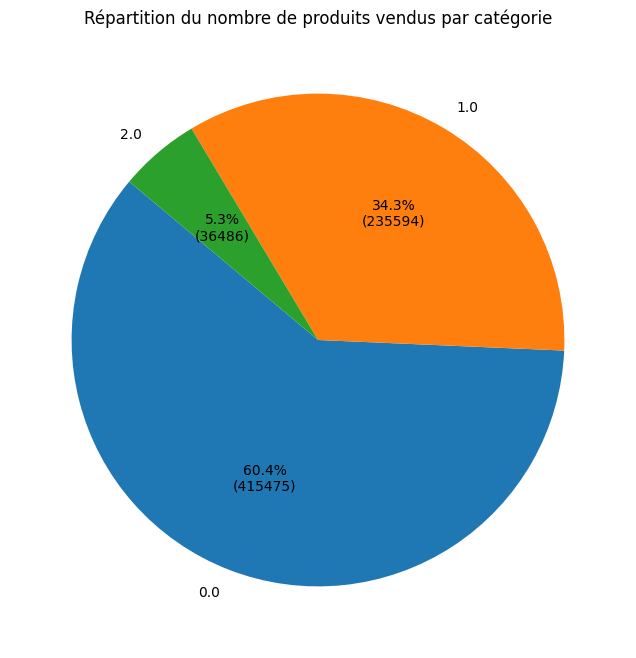

In [34]:
resultat = df_merge.groupby('categ').size().reset_index(name='nb_produits_vendus')

# Fonction pour afficher valeur et pourcentage
def autopct_value_and_percent(pct, allvals):
    total = sum(allvals)
    # Nombre de produits correspondant au pourcentage actuel
    val = int(round(pct * total / 100.0))
    return f"{pct:.1f}%\n({val:d})"

plt.figure(figsize=(8, 8))

# Création du pie chart
plt.pie(
    resultat['nb_produits_vendus'],
    labels=resultat['categ'],
    autopct=lambda pct: autopct_value_and_percent(pct, resultat['nb_produits_vendus']),
    startangle=140
)

plt.title("Répartition du nombre de produits vendus par catégorie")
plt.show()


In [35]:
#comparaison de moyenne entre deux groupe anova
import statsmodels.api as sm
from statsmodels.formula.api import ols

df_merge['ca_group'] = pd.qcut(df_merge['price'], q=4, labels=["Faible", "Moyen-Faible", "Moyen-Élevé", "Élevé"])

bins = [0, 5, 10, 20, df_merge['price'].max()]
labels = ['Très faible', 'Faible', 'Moyen', 'Élevé']
df_merge['ca_group'] = pd.cut(df_merge['price'], bins=bins, labels=labels, include_lowest=True)

# ANOVA: chiffre d'affaires (price) expliqué par la catégorie (categ)
model = ols('price ~ C(categ)', data=df_merge).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                sum_sq        df              F  PR(>F)
C(categ)  1.474527e+08       2.0  623356.079033     0.0
Residual  8.131901e+07  687552.0            NaN     NaN


La répartition du CA entre les catégories

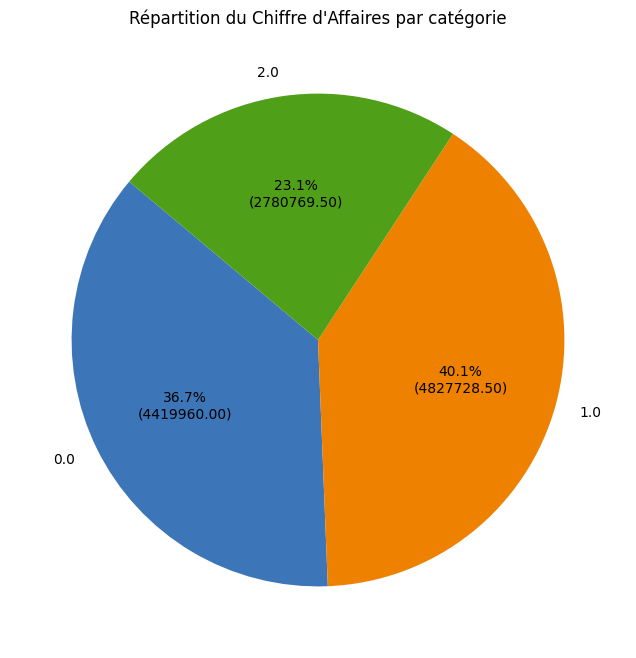

In [36]:
resultat_ca = df_merge.groupby('categ')['price'].sum().reset_index(name='chiffre_affaires')

resultat_ca = resultat_ca[resultat_ca['categ'].isin([1, 2, 0])]

def autopct_value_and_percent(pct, allvals):
    total = sum(allvals)
    val = pct * total / 100.0
    return f"{pct:.1f}%\n({val:.2f})"

# Couleurs par catégorie
colors_map = {
    1: '#ef8100',  # Catégorie 0
    2: '#4f9f19',  # Catégorie 1
    0: '#3d76b8'   # Catégorie 2
}

color_list = [colors_map[c] for c in resultat_ca['categ']]

plt.figure(figsize=(8, 8))

# Création du pie chart
plt.pie(
    resultat_ca['chiffre_affaires'],
    labels=resultat_ca['categ'],
    autopct=lambda pct: autopct_value_and_percent(pct, resultat_ca['chiffre_affaires']),
    colors=color_list,
    startangle=140
)

plt.title("Répartition du Chiffre d'Affaires par catégorie")
plt.show()

In [37]:
#comparaison de moyenne entre deux groupes anova
df_counts = df_merge.groupby('categ').size().reset_index(name='nb_ventes')

df_merge = df_merge.merge(df_counts, on='categ', how='left')

model_ventes = ols('nb_ventes ~ C(categ)', data=df_merge).fit()
anova_ventes = sm.stats.anova_lm(model_ventes, typ=2)

print(anova_ventes)

                sum_sq        df             F  PR(>F)
C(categ)  8.268919e+15       2.0  1.424491e+37     0.0
Residual  1.995559e-16  687552.0           NaN     NaN


Le CA B2B

In [38]:
df_b2b = df_merge[df_merge['client_id'].str.startswith('b', na=False)]

df_b2b

#pas de B2B

,id_prod,date,session_id,client_id,sex,birth,price,categ,age,price_quartile,month,mois_nom,ca_group,nb_ventes


La courbe de Lorenz

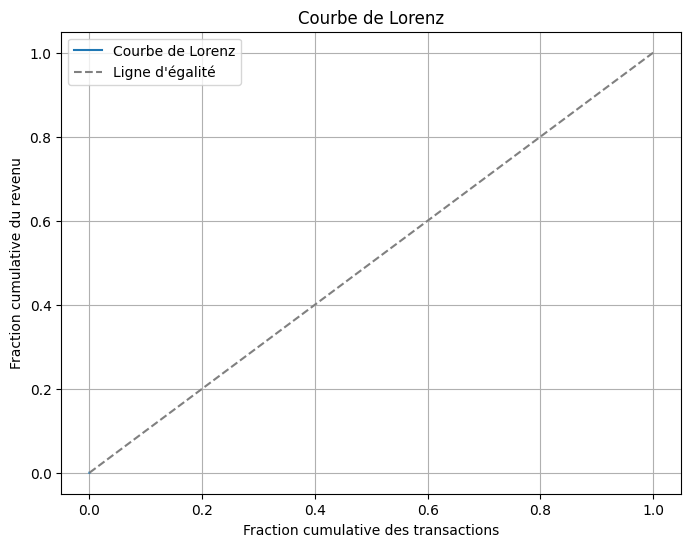

In [39]:
import numpy as np
# On suppose que 'price' représente le revenu par transaction dans df_merge
revenus = np.sort(df_merge['price'].values)  # tri en ordre croissant

# Calcul de la somme cumulative des revenus
cum_revenus = np.cumsum(revenus)

# Normalisation pour obtenir la part cumulée (entre 0 et 1)
total_revenu = cum_revenus[-1]
lorenz = cum_revenus / total_revenu

# On ajoute le point de départ (0, 0)
lorenz = np.insert(lorenz, 0, 0)

# Calcul de la fraction cumulée des transactions
n = len(revenus)
population = np.linspace(0, 1, n + 1)

# Tracé de la courbe de Lorenz
plt.figure(figsize=(8, 6))
plt.plot(population, lorenz, drawstyle='steps-post', label='Courbe de Lorenz')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Ligne d\'égalité')
plt.xlabel('Fraction cumulative des transactions')
plt.ylabel('Fraction cumulative du revenu')
plt.title('Courbe de Lorenz')
plt.legend()

# Ajout du cadrillage
plt.grid(True)

plt.show()

*Commentaire de la courbe de Lorenz :*

*La courbe de Lorenz se confond avec la ligne d'égalité. Donc 10% des transactions génèrent 10% du revenu. Chaque transaction contribue de façon parfaitement égale au revenu total.*

Le prix moyen par catégorie

In [40]:
prix_moyen_par_categ = df_merge.groupby('categ')['price'].mean().reset_index()

# Affichage du résultat
print(prix_moyen_par_categ)

   categ      price
0    0.0  10.638330
1    1.0  20.491730
2    2.0  76.214704


Nb de ventes vs CA par livre

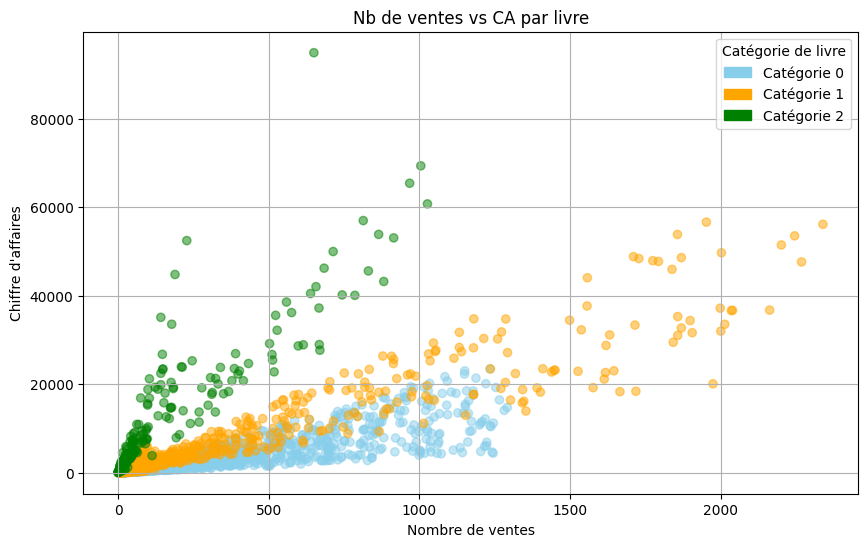

In [41]:
import matplotlib.patches as mpatches

df_categ = df_merge.groupby('id_prod')['categ'].first().reset_index()

df_grouped = df_merge.groupby('id_prod').agg(
    ca_total=('price', 'sum'),
    nb_ventes=('id_prod', 'count')
).reset_index()

df_grouped = df_grouped.merge(df_categ, on='id_prod')

color_map = {0: 'skyblue', 1: 'orange', 2: 'green'}
colors = df_grouped['categ'].map(color_map)

plt.figure(figsize=(10,6))
plt.scatter(df_grouped['nb_ventes'], df_grouped['ca_total'], c=colors, alpha=0.5)

legend_elements = [
    mpatches.Patch(color='skyblue', label='Catégorie 0'),
    mpatches.Patch(color='orange', label='Catégorie 1'),
    mpatches.Patch(color='green', label='Catégorie 2')
]
plt.legend(handles=legend_elements, title='Catégorie de livre')

plt.xlabel("Nombre de ventes")
plt.ylabel("Chiffre d'affaires")
plt.title("Nb de ventes vs CA par livre")
plt.grid(True)
plt.show()

# Demandes de Julie

Lien entre le genre et la categorie des livres achetés

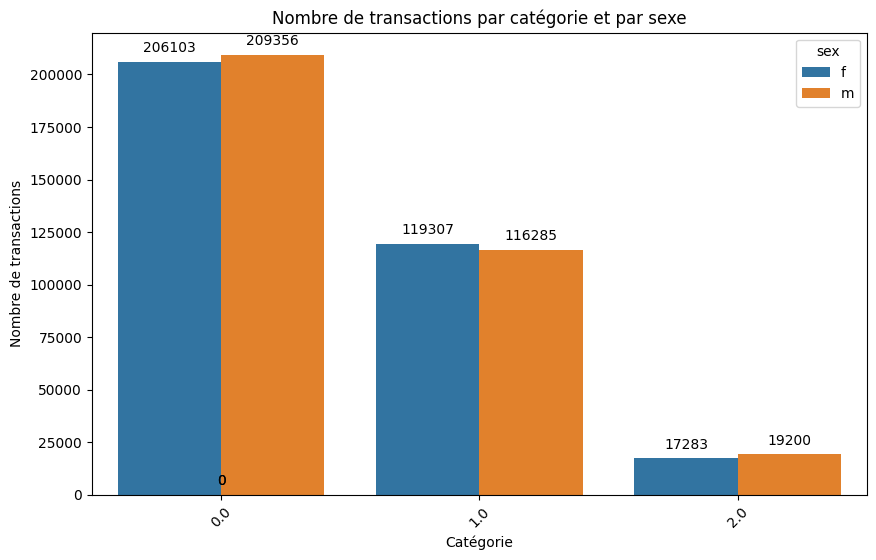

In [42]:
import seaborn as sns

correlation_1 = transactions_customers_products.groupby(["sex","categ"]).agg(count_sex=("sex", "count")).reset_index()

plt.figure(figsize=(10,6))
ax = sns.barplot(x="categ", y="count_sex", hue="sex", data=correlation_1)

# Affichage des valeurs sur chaque barre
for patch in ax.patches:
    height = patch.get_height()
    x = patch.get_x() + patch.get_width() / 2
    ax.annotate(f'{int(height)}', (x, height),
                ha='center', va='bottom',
                fontsize=10, color='black',
                textcoords="offset points", xytext=(0,5))



plt.title("Nombre de transactions par catégorie et par sexe")
plt.xlabel("Catégorie")
plt.ylabel("Nombre de transactions")
plt.xticks(rotation=45)
plt.show()

In [43]:
#Verification du lien entre 2 catégorie chi2
# Construction du tableau de contingence
contingency_table = correlation_1.pivot(index="categ", columns="sex", values="count_sex").fillna(0)
print("Tableau de contingence :")
print(contingency_table)

# Application du test du Khi-deux
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print("\nChi2 :", chi2)
print("p-value :", p_value)
print("Degrés de liberté :", dof)

Tableau de contingence :
sex         f       m
categ                
0.0    206103  209356
1.0    119307  116285
2.0     17283   19200

Chi2 : 158.25417617304882
p-value : 4.3205822283997063e-35
Degrés de liberté : 2


Lien entre l'age des clients et le montant des achats

In [44]:
def generation(year):
  if 1930 <= year <= 1945:
    return "5_Génération Silencieuse / Avant Baby Boom (59-75+ ans)"
  elif 1946 <= year <= 1964:
    return "4_Génération Baby Boom (40-58 ans)"
  elif 1965 <= year <= 1980:
    return "3_Génération X (24-39 ans)"
  elif 1981 <= year <= 1996:
    return "2_Génération Y / Millenial (8-23 ans)"
  elif 1997 <= year <= 2012:
    return "1_Génération Z (-22 ans)"
  else:
    return "0_Aucune génération correspondante"

df_merge['generation'] = df_merge['birth'].apply(generation)

df_generation = df_merge.groupby('generation').agg(
    nb_produits=('id_prod', 'count'),
    sum_price=('price', 'sum')
).reset_index()

df_generation

,generation,nb_produits,sum_price
0,0_Aucune génération correspondante,223,4045.12
1,1_Génération Z (-22 ans),53828,2216372.30
2,2_Génération Y / Millenial (8-23 ans),244519,4004114.24
3,3_Génération X (24-39 ans),282568,4012889.86
4,4_Génération Baby Boom (40-58 ans),90592,1523318.45
5,5_Génération Silencieuse / Avant Baby Boom (59...,15825,267718.41


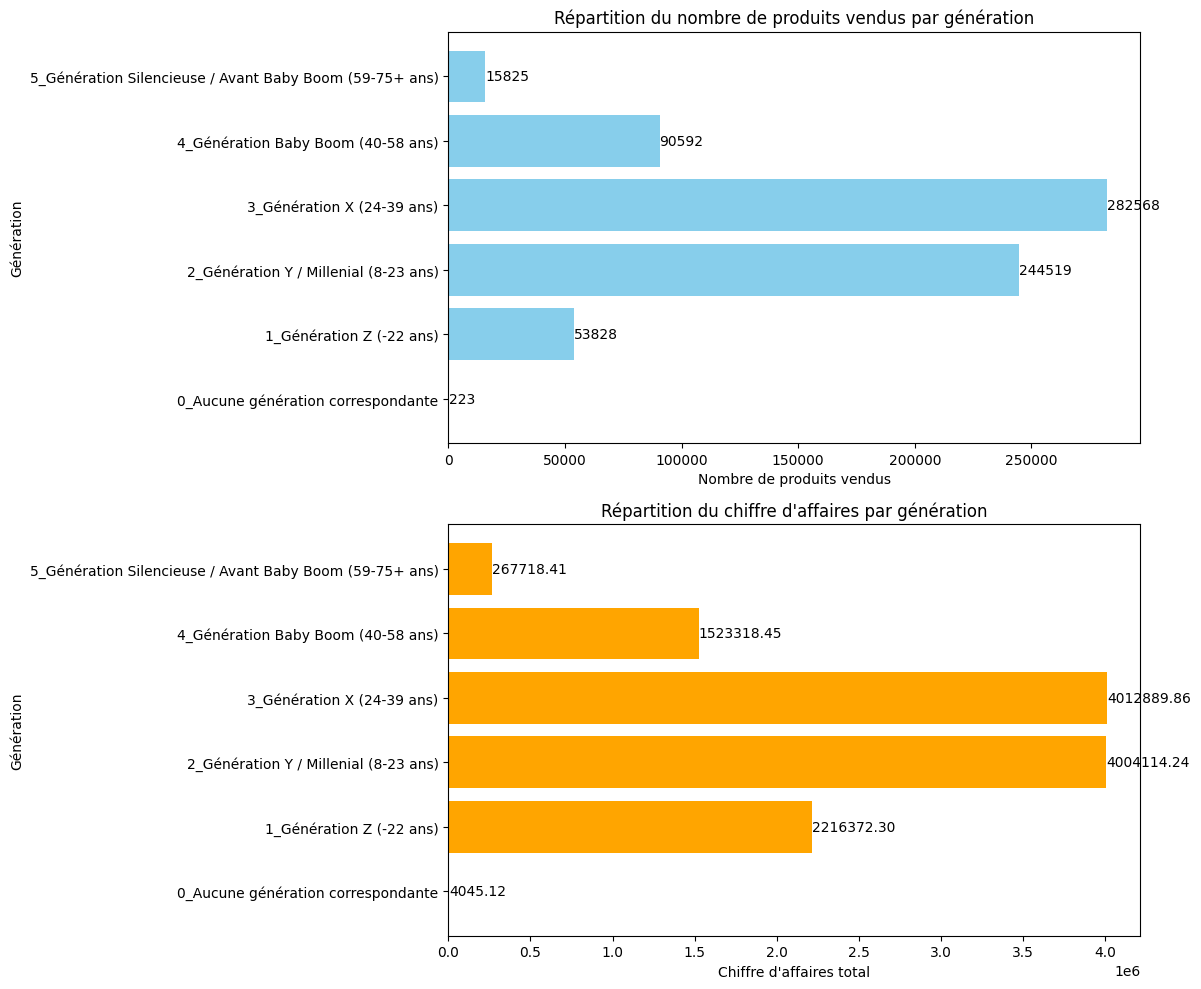

In [45]:
# Préparation des données
values_nb = df_generation['nb_produits']
labels = df_generation['generation']
values_sum = df_generation['sum_price']

# Création de la figure avec deux sous-graphiques (horizontalement)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# ----- Premier bar chart horizontal : nombre de produits vendus -----
ax1.barh(labels, values_nb, color='skyblue')
ax1.set_title("Répartition du nombre de produits vendus par génération")
ax1.set_xlabel("Nombre de produits vendus")
ax1.set_ylabel("Génération")

# Ajouter la valeur à côté de chaque barre
for index, value in enumerate(values_nb):
    ax1.text(value, index, str(value), va='center')

# ----- Deuxième bar chart horizontal : somme des prix -----
ax2.barh(labels, values_sum, color='orange')
ax2.set_title("Répartition du chiffre d'affaires par génération")
ax2.set_xlabel("Chiffre d'affaires total")
ax2.set_ylabel("Génération")

# Ajouter la valeur à côté de chaque barre
for index, value in enumerate(values_sum):
    ax2.text(value, index, f'{value:.2f}', va='center')

plt.tight_layout()
plt.show()

In [46]:
#premier graphique
import numpy as np
from scipy.stats import chisquare

# Observations : nombre de produits vendus par génération
observed = df_generation['nb_produits'].values

total_observed = observed.sum()

expected = np.full_like(observed, fill_value=total_observed / len(observed))

expected = expected * total_observed / expected.sum()

chi2, p_value = chisquare(observed, f_exp=expected)
print("Chi2 :", chi2)
print("p_value :", p_value)

Chi2 : 630062.299448044
p_value : 0.0


In [47]:
#deuxieme graphique
import numpy as np
from scipy.stats import chisquare

# Observations : chiffre d'affaires par génération
observed = df_generation['sum_price'].values

expected = np.full_like(observed, observed.sum() / len(observed))

chi2, p_value = chisquare(f_obs=observed, f_exp=expected)
print("Chi2 :", chi2)
print("p-value :", p_value)


Chi2 : 7645240.149850023
p-value : 0.0


Lien entre l'age des clients et la fréquence des achats

In [48]:
df_frequence_gen = df_merge.groupby('generation').agg(
    nb_transactions=('id_prod', 'count'),
    nb_clients=('client_id', 'nunique')
).reset_index()

df_frequence_gen

,generation,nb_transactions,nb_clients
0,0_Aucune génération correspondante,223,3
1,1_Génération Z (-22 ans),53828,1435
2,2_Génération Y / Millenial (8-23 ans),244519,2647
3,3_Génération X (24-39 ans),282568,2616
4,4_Génération Baby Boom (40-58 ans),90592,1602
5,5_Génération Silencieuse / Avant Baby Boom (59...,15825,297


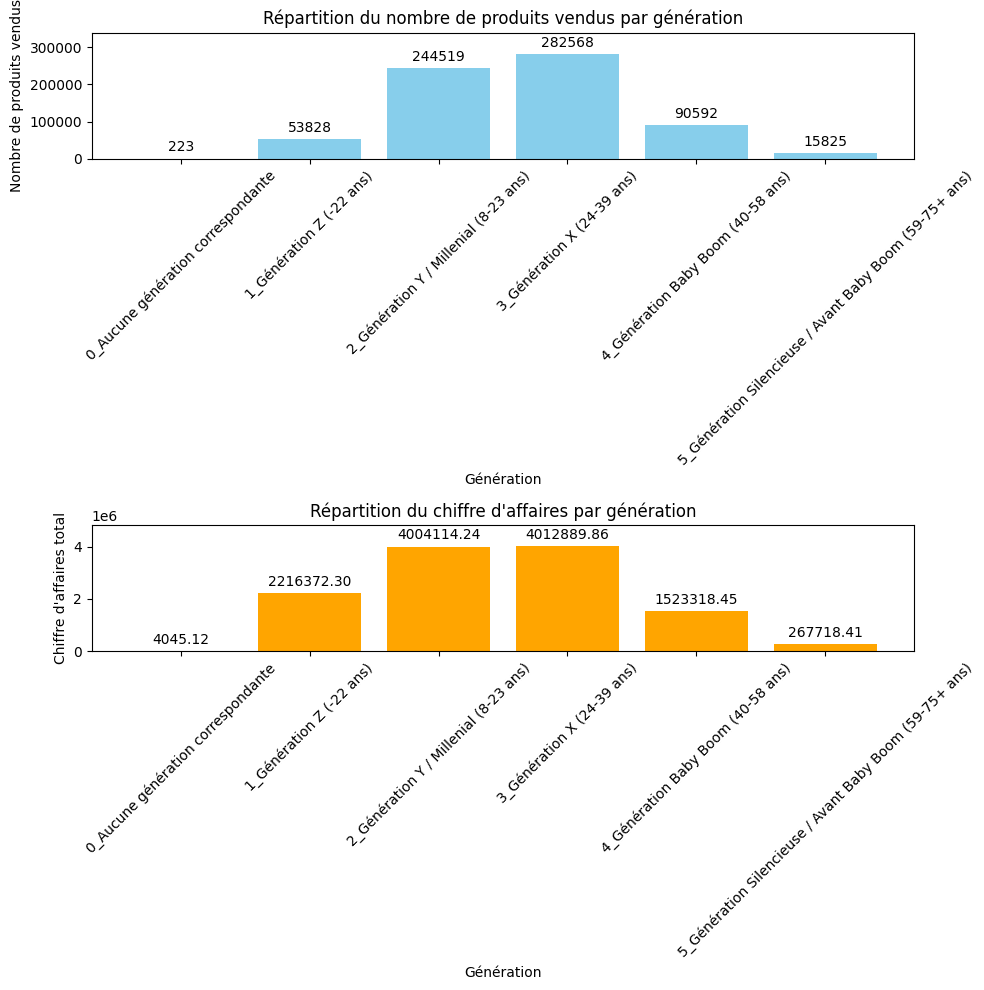

In [49]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# ----- Premier bar chart : nombre de produits vendus -----
bars1 = ax1.bar(df_generation['generation'], df_generation['nb_produits'], color='skyblue')
ax1.set_title("Répartition du nombre de produits vendus par génération")
ax1.set_xlabel("Génération")
ax1.set_ylabel("Nombre de produits vendus")
ax1.tick_params(axis='x', rotation=45)

max_produits = df_generation['nb_produits'].max()
ax1.set_ylim(0, max_produits * 1.2)

for bar in bars1:
    height = bar.get_height()
    ax1.annotate(
        f'{height}',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha='center', va='bottom'
    )

# ----- Deuxième bar chart : somme des prix -----
bars2 = ax2.bar(df_generation['generation'], df_generation['sum_price'], color='orange')
ax2.set_title("Répartition du chiffre d'affaires par génération")
ax2.set_xlabel("Génération")
ax2.set_ylabel("Chiffre d'affaires total")
ax2.tick_params(axis='x', rotation=45)

max_price = df_generation['sum_price'].max()
ax2.set_ylim(0, max_price * 1.2)

for bar in bars2:
    height = bar.get_height()
    ax2.annotate(
        f'{height:.2f}',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha='center', va='bottom'
    )

plt.tight_layout()
plt.show()

In [50]:
#premier graphique

import pandas as pd
from scipy.stats import chi2_contingency

# Tableau de contingence
contingency = pd.crosstab(df_merge['generation'], df_merge['categ'])

# Test du chi²
chi2, p, dof, expected = chi2_contingency(contingency)

print("Statistique de chi² :", chi2)
print("Degrés de liberté :", dof)
print("p-value :", p)

if p < 0.05:
    print("✅ Il y a une dépendance statistique entre la génération et la catégorie de produit.")
else:
    print("❌ Pas de lien significatif entre la génération et la catégorie de produit.")


Statistique de chi² : 191436.5436158405
Degrés de liberté : 10
p-value : 0.0
✅ Il y a une dépendance statistique entre la génération et la catégorie de produit.


In [51]:
#deuxieme graphique
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# On part de ton df_merge
df = df_merge.copy()

# 1. Créer des classes de CA (ex : quartiles sur les prix)
df['price_quartile_group'] = pd.qcut(df['price'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# 2. Faire une table de contingence : génération vs groupe de prix
contingency_table = pd.crosstab(df['generation'], df['price_quartile_group'])

# 3. Appliquer le test du chi²
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi² statistic = {chi2:.2f}")
print(f"Degrés de liberté = {dof}")
print(f"p-value = {p:.4f}")

Chi² statistic = 51837.29
Degrés de liberté = 15
p-value = 0.0000


Lien entre l'age du client et la taille du panier moyen

In [52]:
prod_count_per_client = df_merge.groupby(['generation', 'client_id']).agg(
    nb_produit=('id_prod', 'count'),
    montant_moyen=('price', 'mean')
).reset_index()

df_panier_moy = prod_count_per_client.groupby('generation').agg(
    nb_clients=('client_id', 'nunique'),
    panier_moyen=('nb_produit', 'mean'),
    montant_moyen=('montant_moyen', 'mean')
).reset_index()

df_panier_moy

,generation,nb_clients,panier_moyen,montant_moyen
0,0_Aucune génération correspondante,3,67.333333,16.099533
1,1_Génération Z (-22 ans),1435,37.510801,41.203425
2,2_Génération Y / Millenial (8-23 ans),2647,92.375897,22.193484
3,3_Génération X (24-39 ans),2616,108.015291,14.810187
4,4_Génération Baby Boom (40-58 ans),1602,56.549313,16.768458
5,5_Génération Silencieuse / Avant Baby Boom (59...,297,53.282828,17.008658


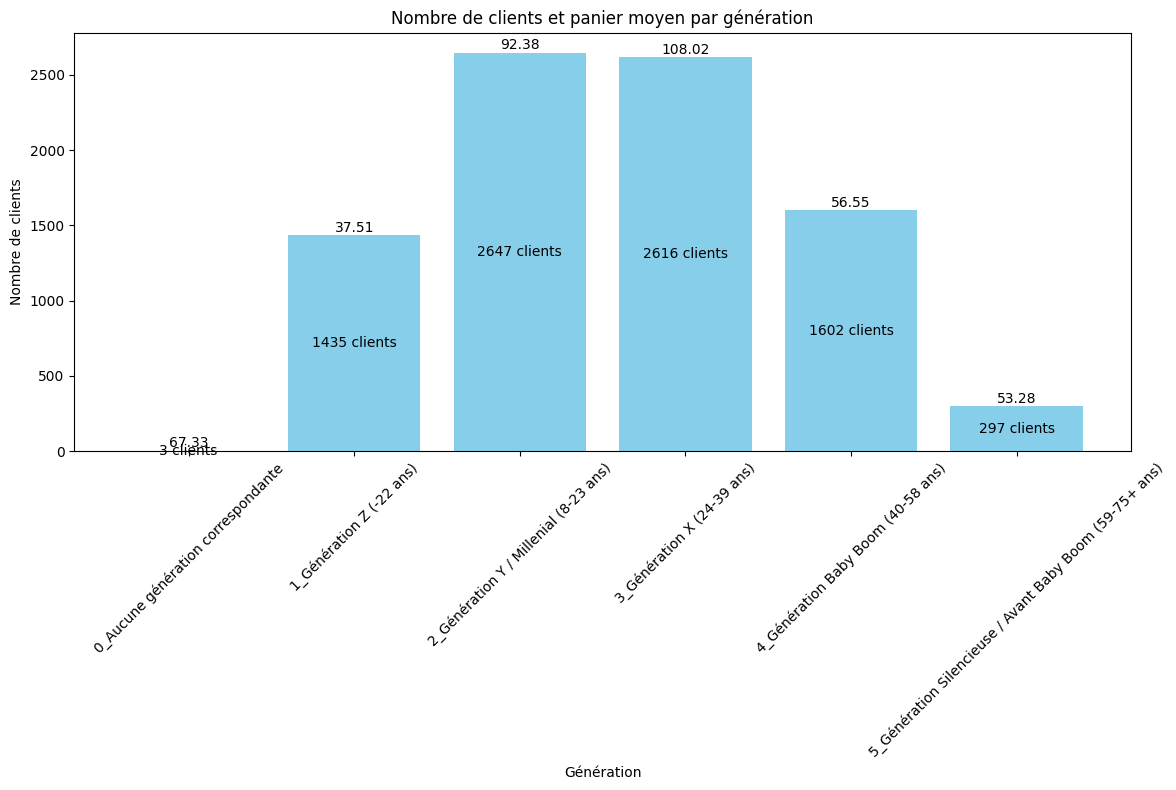

In [53]:
import matplotlib.pyplot as plt

# Préparation des données
labels = df_panier_moy['generation']
values_clients = df_panier_moy['nb_clients']
values_panier_moyen = df_panier_moy['panier_moyen']

# Création de la figure
fig, ax = plt.subplots(figsize=(12, 8))

# Création du bar chart vertical
bars = ax.bar(labels, values_clients, color='skyblue')
ax.set_title("Nombre de clients et panier moyen par génération")
ax.set_ylabel("Nombre de clients")
ax.set_xlabel("Génération")

# Ajouter les valeurs dans la barre et le panier moyen au-dessus de chaque barre
for bar, panier in zip(bars, values_panier_moyen):
    height = bar.get_height()
    # Texte au milieu de la barre pour le nombre de clients
    ax.text(bar.get_x() + bar.get_width() / 2, height / 2, f"{int(height)} clients",
            ha='center', va='center', color='black', fontsize=10)
    # Texte au-dessus de la barre pour le panier moyen
    ax.text(bar.get_x() + bar.get_width() / 2, height + 2, f"{panier:.2f}",
            ha='center', va='bottom', color='black', fontsize=10)

# Rotation des étiquettes de l'axe des x en diagonale
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [54]:
import scipy.stats as stats

corr, p_value = stats.pearsonr(df_panier_moy['nb_clients'], df_panier_moy['panier_moyen'])
print("Coefficient de Pearson :", corr)
print("p-value :", p_value)


Coefficient de Pearson : 0.629929706646693
p-value : 0.18008709555128757


Lien entre l'age des clients et la categorie des livres achetés

In [55]:
age_category = df_merge.pivot_table(index='generation', columns='categ',aggfunc='size',fill_value=0).reset_index()

age_category.columns = ['generation'] + [f'categ_{col}' for col in age_category.columns[1:]]

age_category

,generation,categ_0.0,categ_1.0,categ_2.0
0,0_Aucune génération correspondante,94,125,4
1,1_Génération Z (-22 ans),10849,20907,22072
2,2_Génération Y / Millenial (8-23 ans),169162,63402,11955
3,3_Génération X (24-39 ans),189895,91175,1498
4,4_Génération Baby Boom (40-58 ans),38785,51011,796
5,5_Génération Silencieuse / Avant Baby Boom (59...,6690,8974,161


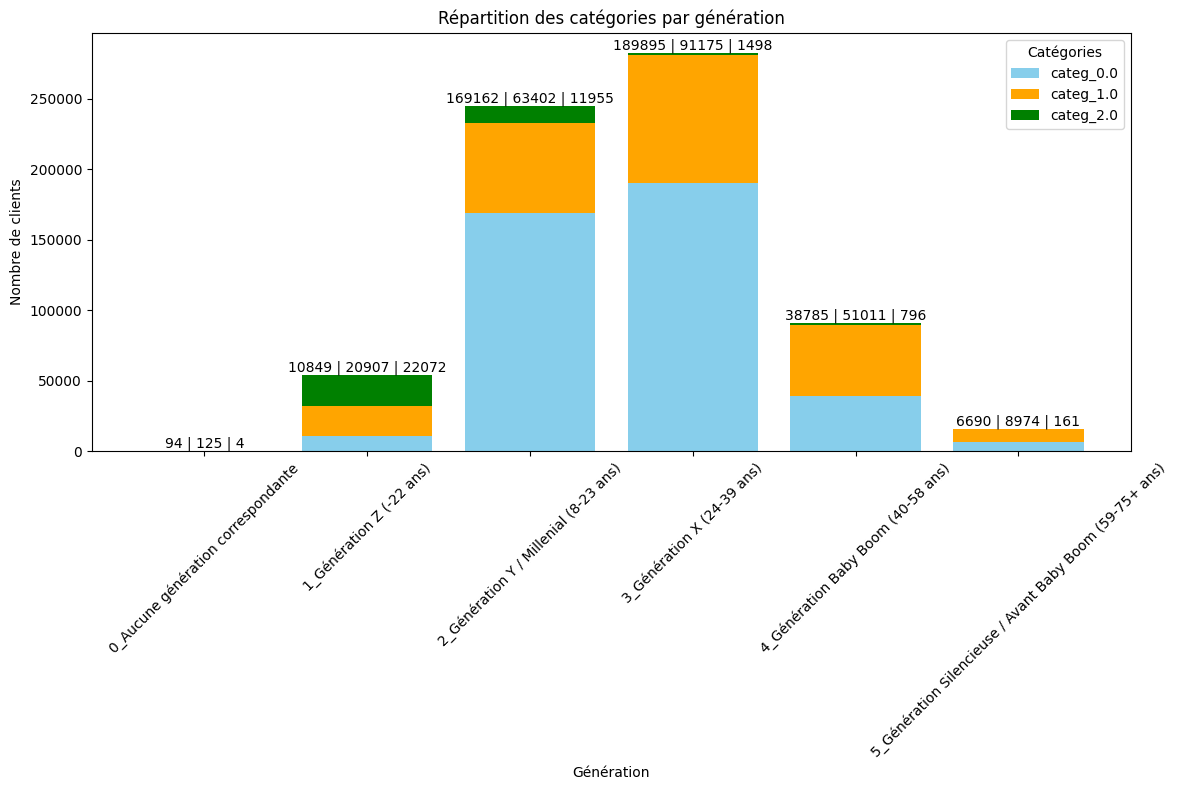

In [56]:
import matplotlib.pyplot as plt
import numpy as np

# Préparation des données
labels = age_category['generation']
categories = age_category.columns[1:]
values = age_category[categories].values  # shape: (nombre de générations, nombre de catégories)

# Création de la figure
fig, ax = plt.subplots(figsize=(12, 8))

x = np.arange(len(labels))  # positions sur l'axe x pour chaque génération
bars_bottom = np.zeros(len(labels))
colors = ['skyblue', 'orange', 'green', 'red', 'purple']  # Couleurs pour les catégories

# Création du bar chart empilé vertical
for i, (category, color) in enumerate(zip(categories, colors)):
    heights = values[:, i]
    ax.bar(x, heights, bottom=bars_bottom, label=category, color=color)
    bars_bottom += heights

# Ajouter les valeurs en bout de barre (texte au-dessus de chaque stack)
for i, label in enumerate(labels):
    total_value = sum(values[i, :])
    # Concaténation des valeurs de chaque catégorie pour cette génération
    text_str = " | ".join(str(age_category.iloc[i, j+1]) for j in range(len(categories)))
    ax.text(x[i], total_value + 2, text_str, ha='center', va='bottom', fontsize=10, color='black')

ax.set_title("Répartition des catégories par génération")
ax.set_xlabel("Génération")
ax.set_ylabel("Nombre de clients")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend(title="Catégories")

plt.tight_layout()
plt.show()


In [57]:
import pandas as pd
from scipy.stats import chi2_contingency

# On construit le tableau de contingence en utilisant 'generation' comme index
contingency_table = age_category.set_index('generation')

# Application du test du Khi-deux d'indépendance
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print("\nChi2 :", chi2)
print("p-value :", p_value)
print("Degrés de liberté :", dof)


Chi2 : 191436.5436158405
p-value : 0.0
Degrés de liberté : 10
